In [1]:
# Standard library imports
import os
import sys
import json
import pickle
import random
import re
from glob import glob
from pathlib import Path

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cv2
from tqdm import tqdm
import scipy

# PyTorch imports
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

# torchvision imports
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
from torchvision.datasets import VisionDataset
import torchvision.transforms as T

# PIL imports
from PIL import Image

In [2]:
from datasets import ISICDataset, HAM10000Dataset, PH2Dataset, BCN20000Dataset

In [3]:
img_dir = "/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/PH2"
folders = ["dark_corner_6",  "gel_bubble_1",  "ink_4_no_ruler",  "patches_3",  "ruler_1"]

In [4]:
def numerical_sort(path):
    filename = os.path.basename(path)  # Get only the filename (e.g., "img_839.png")
    numbers = re.findall(r'\d+', filename)  # Extract numbers
    return int(numbers[0]) if numbers else float('inf')  # Convert to integer for sorting

# Visualize

In [12]:
folder = "patches_3"
image_paths = []
folder_path = os.path.join(img_dir, folder)
image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".png")]
image_files.sort(key=numerical_sort)  # Sort by extracted numeric value
image_paths.extend(image_files)

In [13]:
def display_images(image_paths, start_index=0):
    batch_size = 25  # Fixed 5x5 grid (25 images)
    end_index = min(start_index + batch_size, len(image_paths))
    
    if start_index >= len(image_paths):
        print("Start index exceeds the number of images.")
        return
    
    fig, axes = plt.subplots(5, 5, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        img_idx = start_index + i
        if img_idx < end_index:
            img_path = image_paths[img_idx]
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for Matplotlib
            ax.imshow(img)
            ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis("off")  # Hide axes

    plt.tight_layout()
    plt.show()

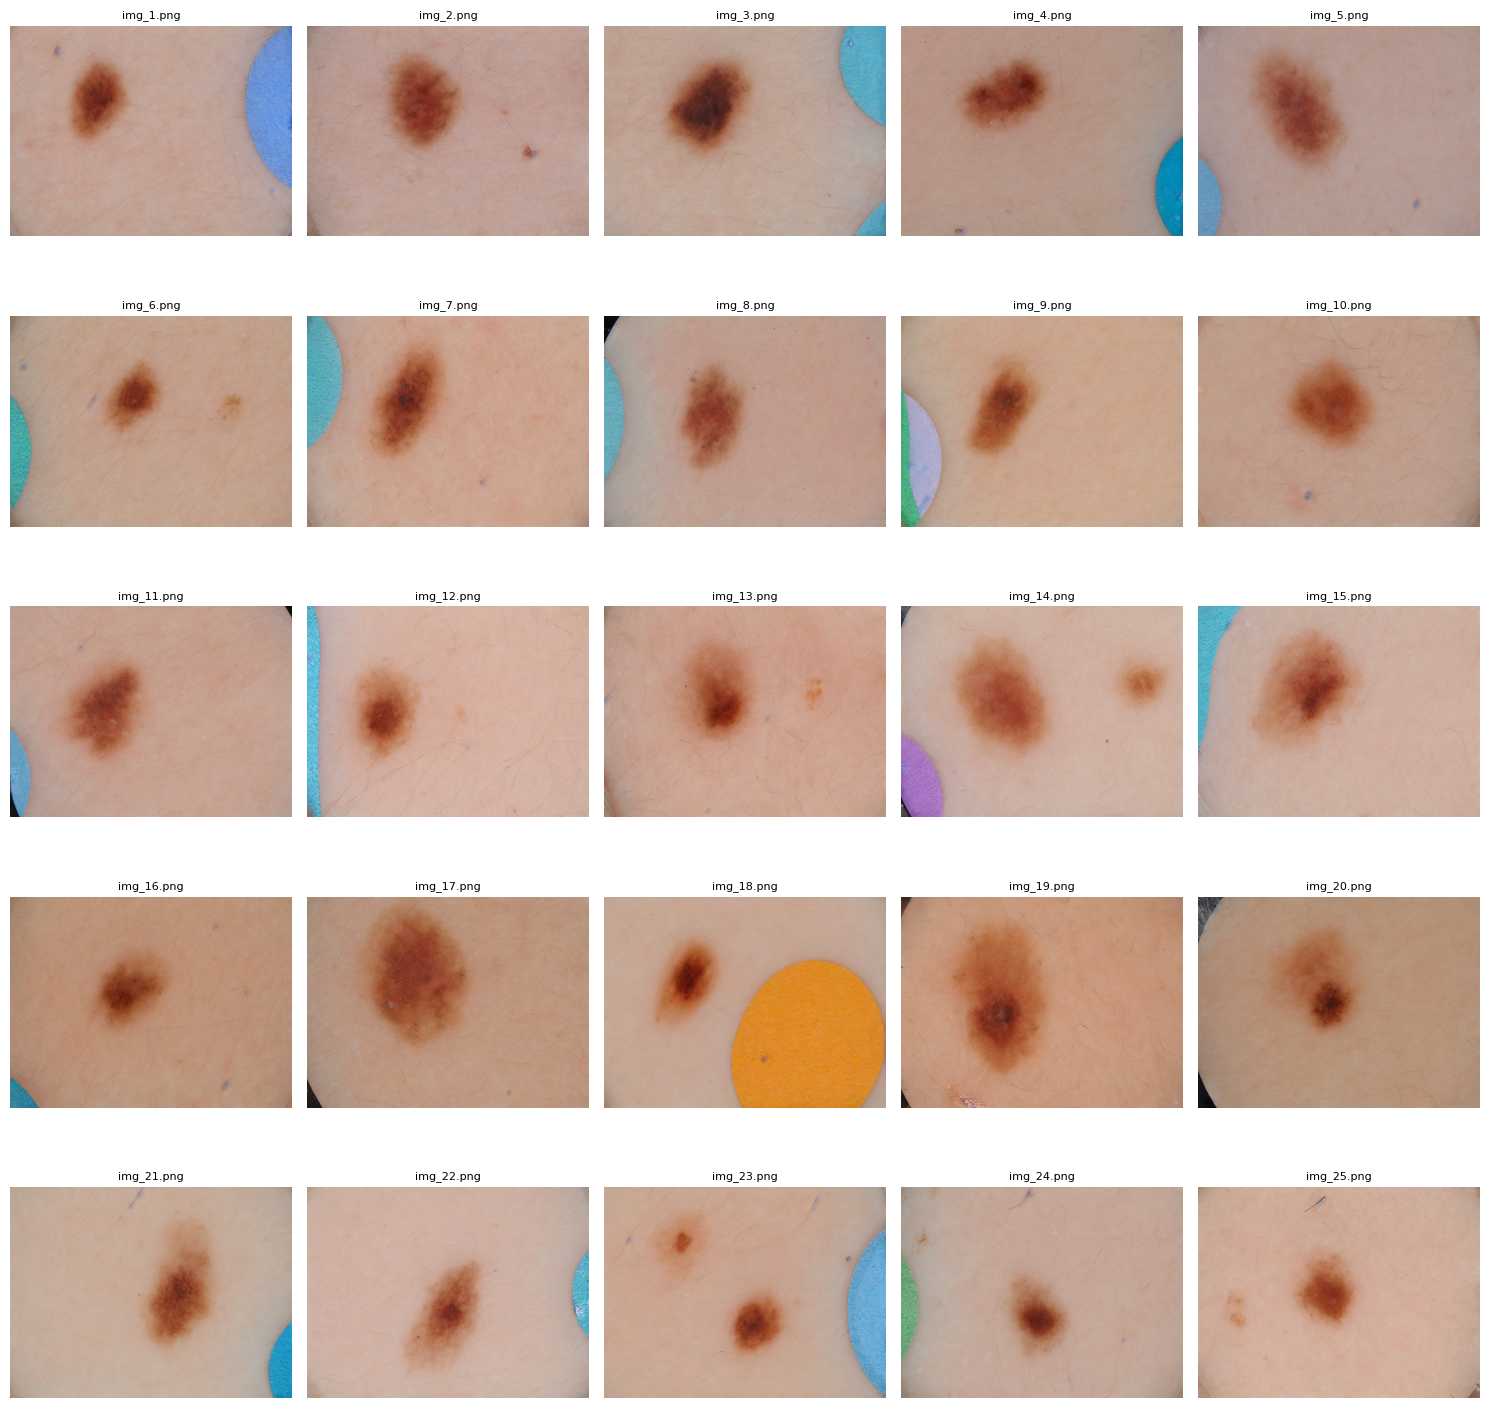

In [14]:
display_images(image_paths, start_index=0)

In [6]:
image_dir = "/mnt/scratch-lids/data/PH2Dataset/images/"
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col=0)
ph2_dataset = PH2Dataset(df, image_dir, mode="whole", return_pil=True, return_mask=True)

In [8]:
ph2_dataset[0]

(<PIL.Image.Image image mode=RGB size=768x576>,
 tensor(1),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

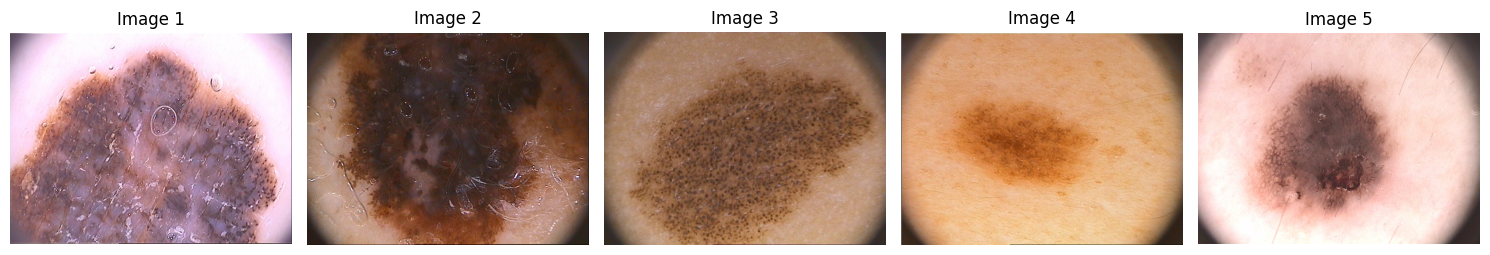

In [19]:
ph2_start = 0
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))  # 1 row, 5 columns

for i in range(num_images):
    sample = ph2_dataset[ph2_start + i]  # Retrieve dataset entry
    img = sample[0]  # First entry is the PIL image

    axes[i].imshow(img)  # Display the image
    axes[i].axis("off")  # Hide axes
    axes[i].set_title(f"Image {i+1}")  # Set title

plt.tight_layout()
plt.show()

# Revised lesion images

In [ ]:
img_dir = "/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/PH2"
folders = ["dark_corner_6",  "gel_bubble_1",  "ink_4_no_ruler",  "patches_3",  "ruler_1"]

In [ ]:
image_dir = "/mnt/scratch-lids/data/PH2Dataset/images/"
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col=0)
ph2_dataset = PH2Dataset(df, image_dir, mode="whole", return_pil=True, return_mask=True)

In [35]:
folder = "dark_corner_6"

image_paths = []
folder_path = os.path.join(img_dir, folder)
image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".png")]
image_files.sort(key=numerical_sort)  # Sort by extracted numeric value
image_paths.extend(image_files)

In [36]:
revised_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/{folder}"
os.makedirs(revised_dir, exist_ok=True)

In [37]:
# Process each PH2 dataset entry
for i, (source_image, _, lesion_mask) in tqdm(enumerate(ph2_dataset)):
    
    # Convert lesion mask to binary mask
    lesion_mask = Image.fromarray((lesion_mask * 255).astype(np.uint8)).convert("L")

    # Extract lesion by applying the mask
    lesion_only = Image.new("RGBA", source_image.size, (0, 0, 0, 0))  # Transparent background
    source_rgba = source_image.convert("RGBA")  # Ensure RGBA mode
    for x in range(source_image.width):
        for y in range(source_image.height):
            if lesion_mask.getpixel((x, y)) > 128:  # If in lesion area
                lesion_only.putpixel((x, y), source_rgba.getpixel((x, y)))

    # Get the corresponding 5 images
    start_idx = i * 5
    for j in range(5):
        if start_idx + j >= len(image_files):
            break  # Avoid index errors if images are missing

        target_path = image_files[start_idx + j]
        target_image = Image.open(target_path).convert("RGBA")

        # Paste the lesion onto the target image
        blended_image = target_image.copy()
        blended_image.paste(lesion_only, (0, 0), mask=lesion_mask)

        # Save revised image
        save_path = os.path.join(revised_dir, f"img_{1+start_idx + j}.png")
        blended_image.save(save_path)

print(f"Revised images saved to {revised_dir}")

200it [08:05,  2.43s/it]

Revised images saved to /mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/dark_corner_6


In [40]:
revised_dir

'/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/dark_corner_6'

# Artifact classifier pick positive

In [42]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import numpy as np
import pickle

In [16]:
mapping = {
    "dark_corner": "/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/dark_corner_6", 
    "gel_bubble": "/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/gel_bubble_1", 
    "ink": "/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/ink_4_no_ruler", 
    "patches": "/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/patches_3", 
    "ruler": "/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/ruler_1", 
}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [17]:
artifacts = list(mapping.keys())

In [76]:
artifacts

['dark_corner', 'gel_bubble', 'ink', 'patches', 'ruler']

In [41]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [77]:
# Load the trained model
model_dir = "/mnt/scratch-lids/scratch/qixuanj/chil2025/artifact_classifiers2" 

results = {}
results['preds'] = {}
results['probs'] = {}
for artifact in ['patches', 'ruler']: 
    print(artifact)
    results['preds'][artifact] = {}
    results['probs'][artifact] = {}
    
    test_dir = mapping[artifact]
    test_image_paths = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith((".png", ".jpg", ".jpeg"))]
    test_image_paths.sort(key=numerical_sort)
    
    for j in range(1, 6): 
        model = models.resnet50(pretrained=False)  # Define model architecture
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 1)
        model = model.to(DEVICE)
        
        model_path = f"{model_dir}/{artifact}_classifier_split_{j}.pth"
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()  # Set model to evaluation mode
        
        all_probs = []
        all_preds = []
        
        with torch.no_grad():
            for img_path in tqdm(test_image_paths, desc=f"Model {j}: Processing Images"):
                try:
                    img = Image.open(img_path).convert("RGB")  # Load image and convert to RGB
                except: 
                    all_probs.append(0)
                    all_preds.append(0)
                    continue
                img = transform(img)  # Apply transformations
                img = img.unsqueeze(0).to(DEVICE)
                
                output = model(img).squeeze()  # Ensure shape is (batch_size,)
                prob = torch.sigmoid(output).item()  # Convert logit to probability
                pred = 1 if prob > 0.5 else 0  # Binary classification
                
                all_probs.append(prob)
                all_preds.append(pred)
    
        # Convert lists to numpy arrays
        all_probs = np.array(all_probs)
        all_preds = np.array(all_preds)
        results['probs'][artifact][j] = all_probs 
        results['preds'][artifact][j] = all_preds 

# with open("/mnt/scratch-lids/scratch/qixuanj/chil2025/artifact_preds2/PH2_augmented_predictions.pkl", "wb") as f: 
#     pickle.dump(results,f)

patches


/tmp/ipykernel_625389/2364511169.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))
Model 5: Processing 

ruler


Model 5: Processing Images: 100%|██████████████████████████████████████████████████████████████| 1000/1000 [00:25<00:00, 39.71it/s]


In [80]:
results['preds'].keys()

dict_keys(['patches', 'ruler'])

In [78]:
with open("/mnt/scratch-lids/scratch/qixuanj/chil2025/artifact_preds2/PH2_augmented_predictions.pkl", "rb") as f: 
    results1 = pickle.load(f)

In [81]:
results1['preds']['ruler'] = {}
results1['probs']['ruler'] = {}

In [82]:
for j in range(1, 6):
    results1['preds']['patches'][j] = results['preds']['patches'][j]
    results1['probs']['patches'][j] = results['probs']['patches'][j]
    results1['preds']['ruler'][j] = results['preds']['ruler'][j]
    results1['probs']['ruler'][j] = results['probs']['ruler'][j]

In [85]:
with open("/mnt/scratch-lids/scratch/qixuanj/chil2025/artifact_preds2/PH2_augmented_predictions.pkl", "wb") as f: 
    pickle.dump(results1,f)

In [86]:
results = results1

In [87]:
majority_votes = {artifact: [] for artifact in artifacts if artifact in results['preds']}
# Get number of samples (assume all splits have the same number of samples)
num_samples = len(next(iter(results['preds']['dark_corner'].values())))

# Compute majority vote for each artifact
for artifact in majority_votes.keys():
    votes = np.zeros((num_samples, len(results['preds'][artifact])))

    # Collect predictions across splits
    for i, split in enumerate(results['preds'][artifact]):
        votes[:, i] = results['preds'][artifact][split]

    # Compute majority vote (round mean to get majority class)
    majority_votes[artifact] = np.round(np.mean(votes, axis=1)).astype(int)

# Convert results to a DataFrame
df_majority_votes = pd.DataFrame(majority_votes)

In [88]:
# Initialize dictionary to store mean probabilities
mean_probabilities = {artifact: [] for artifact in artifacts if artifact in results['probs']}

# Get number of samples (assume all splits have the same number of samples)
num_samples = len(next(iter(results['probs']['dark_corner'].values())))

# Compute mean probability for each artifact
for artifact in mean_probabilities.keys():
    probs = np.zeros((num_samples, len(results['probs'][artifact])))

    # Collect predictions (probabilities) across splits
    for i, split in enumerate(results['probs'][artifact]):
        probs[:, i] = results['probs'][artifact][split]  # Assuming stored as probability values (0-1)

    # Compute mean probability across splits
    mean_probabilities[artifact] = np.mean(probs, axis=1)  # No rounding

# Convert results to a DataFrame
df_mean_probabilities = pd.DataFrame(mean_probabilities)

In [89]:
df_majority_votes

,dark_corner,gel_bubble,ink,patches,ruler
0,1,1,1,1,0
1,1,1,1,0,1
2,1,1,1,1,0
3,1,1,0,0,0
4,1,1,1,0,0
...,...,...,...,...,...
995,1,1,1,0,1
996,1,1,1,1,1
997,1,1,1,1,1
998,1,1,0,1,1


In [90]:
df_majority_votes.mean(axis=0)

dark_corner    0.957
gel_bubble     0.937
ink            0.755
patches        0.517
ruler          0.681
dtype: float64

In [91]:
df_majority_votes.sum(axis=0)

dark_corner    957
gel_bubble     937
ink            755
patches        517
ruler          681
dtype: int64

In [92]:
df_majority_votes.to_csv(f"/mnt/scratch-lids/scratch/qixuanj/chil2025/artifact_preds2/PH2_augmented_artifact_labels.csv")

In [93]:
df_mean_probabilities

,dark_corner,gel_bubble,ink,patches,ruler
0,0.999426,0.998499,0.942020,0.649184,0.138865
1,0.998945,0.999717,0.677837,0.009632,0.965478
2,0.934173,0.999254,0.985255,0.743584,0.099334
3,0.985970,0.998189,0.108960,0.011431,0.135172
4,0.998034,0.998417,0.997833,0.021130,0.086554
...,...,...,...,...,...
995,0.997846,0.951894,0.996605,0.220872,0.923343
996,0.996922,0.696401,0.999991,0.998393,0.995449
997,0.999391,0.553323,0.738783,0.976515,0.999652
998,0.998088,0.887976,0.008566,0.998651,0.996161


In [102]:
df_binary = pd.DataFrame(0, index=df_mean_probabilities.index, columns=df_mean_probabilities.columns)

# Process every 5-row block
for start in range(0, len(df_mean_probabilities), 5):
    end = min(start + 5, len(df_mean_probabilities))  # Ensure we don't exceed dataframe size
    subset = df_mean_probabilities.iloc[start:end]  # Select 5-row block
    max_indices = subset.idxmax()  # Get index of max value for each column

    # Ensure only one row per column gets updated
    for col in subset.columns:
        df_binary.loc[max_indices[col], col] = 1  # Set only the highest row to 1

In [103]:
df_binary.sum(axis=0)

dark_corner    200
gel_bubble     200
ink            200
patches        200
ruler          200
dtype: int64

In [104]:
df_binary

,dark_corner,gel_bubble,ink,patches,ruler
0,1,0,0,0,0
1,0,1,0,0,1
2,0,0,0,1,0
3,0,0,0,0,0
4,0,0,1,0,0
...,...,...,...,...,...
995,0,0,0,0,0
996,0,0,1,0,0
997,1,0,0,0,1
998,0,0,0,1,0


In [105]:
df_binary.to_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/img2img/revised_PH2/chosen_images.csv")

In [113]:
artifact = 'dark_corner'

In [108]:
df_binary[df_binary[artifact] == 1].index + 1

Index([  1,   9,  12,  19,  23,  29,  31,  40,  45,  50,
       ...
       951, 957, 964, 967, 974, 979, 984, 986, 992, 998],
      dtype='int64', length=200)

In [111]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col = 0)

In [116]:
for artifact in df_binary.columns:
    df[f'{artifact}_augmented'] = df_binary[df_binary[artifact] == 1].index + 1

In [118]:
df.to_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv")

In [119]:
df

,Name,label,Clinical Diagnosis,Histological Diagnosis,Colors,Asymmetry,Pigment Network,Dots/Globules,Streaks,Regression Areas,...,split_1,split_2,split_3,split_4,split_5,dark_corner_augmented,gel_bubble_augmented,ink_augmented,patches_augmented,ruler_augmented
0,IMD423,1,2,Melanoma,3 4 5,0,AT,AT,A,A,...,test,train,train,train,train,1,2,5,3,2
1,IMD348,1,2,Melanoma,1 4 5 6,2,AT,AT,P,P,...,test,train,train,train,train,9,10,8,6,9
2,IMD044,0,0,NaN,4 5,0,T,T,A,A,...,test,train,train,train,train,12,13,12,11,12
3,IMD125,0,0,NaN,3 4,0,T,T,A,A,...,test,train,train,train,train,19,19,18,16,17
4,IMD004,0,1,NaN,3 4,1,AT,A,A,A,...,test,train,train,train,train,23,23,21,23,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,IMD045,0,0,NaN,3,0,T,T,A,A,...,train,train,train,train,test,979,976,980,976,979
196,IMD413,1,2,Lentigo Maligna,3 4,2,AT,AT,A,A,...,train,train,train,train,test,984,985,982,985,983
197,IMD126,0,1,NaN,3 6,1,AT,A,A,A,...,train,train,train,train,test,986,986,986,987,987
198,IMD421,1,2,Melanoma,1 3 4 5,2,AT,AT,A,P,...,train,train,train,train,test,992,991,993,993,993


# Inference of classifiers on PH2 images

In [11]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col=0)

In [12]:
df

,Name,label,Clinical Diagnosis,Histological Diagnosis,Colors,Asymmetry,Pigment Network,Dots/Globules,Streaks,Regression Areas,...,split_2,split_3,split_4,split_5,dark_corner_augmented,gel_bubble_augmented,ink_augmented,patches_augmented,ruler_augmented,ruler_1_clean
0,IMD423,1,2,Melanoma,3 4 5,0,AT,AT,A,A,...,train,train,train,train,1,2,5,3,2,img_0_3.png
1,IMD348,1,2,Melanoma,1 4 5 6,2,AT,AT,P,P,...,train,train,train,train,9,10,8,6,9,img_1_0.png
2,IMD044,0,0,NaN,4 5,0,T,T,A,A,...,train,train,train,train,12,13,12,11,12,img_2_1.png
3,IMD125,0,0,NaN,3 4,0,T,T,A,A,...,train,train,train,train,19,19,18,16,17,img_3_2.png
4,IMD004,0,1,NaN,3 4,1,AT,A,A,A,...,train,train,train,train,23,23,21,23,22,img_4_0.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,IMD045,0,0,NaN,3,0,T,T,A,A,...,train,train,train,test,979,976,980,976,979,img_195_2.png
196,IMD413,1,2,Lentigo Maligna,3 4,2,AT,AT,A,A,...,train,train,train,test,984,985,982,985,983,img_196_1.png
197,IMD126,0,1,NaN,3 6,1,AT,A,A,A,...,train,train,train,test,986,986,986,987,987,img_197_3.png
198,IMD421,1,2,Melanoma,1 3 4 5,2,AT,AT,A,P,...,train,train,train,test,992,991,993,993,993,img_198_2.png


In [40]:
import os
import re
from glob import glob

# Define the folder path
folder_path = "/data/healthy-ml/scratch/qixuanj/new_generative_validation/inpaint/PH2/ink_4_no_ruler_clean"

# Function to extract the first number from the filename
def extract_first_number(filename):
    match = re.search(r'img_(\d+)_', filename)  # Extracts the first number after "img_"
    return int(match.group(1)) if match else float('inf')  # Convert to int, or put non-matching at the end

# Get all PNG files and sort by the first number
png_files = glob(os.path.join(folder_path, "*.png"))
sorted_files = sorted(png_files, key=extract_first_number)

# Extract just the filename suffixes (e.g., "img_0_3.png")
file_suffixes = [os.path.basename(file) for file in sorted_files]

In [41]:
import re

def find_missing_numbers(filenames, start=1, end=199):
    present_numbers = set()
    pattern = re.compile(r'img_(\d+)_\d+\.png')
    
    for filename in filenames:
        match = pattern.match(filename)
        if match:
            present_numbers.add(int(match.group(1)))
    
    all_numbers = set(range(start, end + 1))
    missing_numbers = sorted(all_numbers - present_numbers)
    
    return missing_numbers

In [42]:
find_missing_numbers(file_suffixes, start=0, end=199)

[]

In [43]:
df['ink_4_no_ruler_clean'] = file_suffixes

In [44]:
df.to_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv")

In [45]:
df

,Name,label,Clinical Diagnosis,Histological Diagnosis,Colors,Asymmetry,Pigment Network,Dots/Globules,Streaks,Regression Areas,...,dark_corner_augmented,gel_bubble_augmented,ink_augmented,patches_augmented,ruler_augmented,ruler_1_clean,gel_bubble_1_clean,dark_corner_6_clean,patches_3_clean,ink_4_no_ruler_clean
0,IMD423,1,2,Melanoma,3 4 5,0,AT,AT,A,A,...,1,2,5,3,2,img_0_3.png,img_0_1.png,img_0_1.png,img_0_2.png,img_0_1.png
1,IMD348,1,2,Melanoma,1 4 5 6,2,AT,AT,P,P,...,9,10,8,6,9,img_1_0.png,img_1_4.png,img_1_1.png,img_1_1.png,img_1_4.png
2,IMD044,0,0,NaN,4 5,0,T,T,A,A,...,12,13,12,11,12,img_2_1.png,img_2_0.png,img_2_0.png,img_2_3.png,img_2_2.png
3,IMD125,0,0,NaN,3 4,0,T,T,A,A,...,19,19,18,16,17,img_3_2.png,img_3_1.png,img_3_1.png,img_3_1.png,img_3_2.png
4,IMD004,0,1,NaN,3 4,1,AT,A,A,A,...,23,23,21,23,22,img_4_0.png,img_4_0.png,img_4_0.png,img_4_2.png,img_4_3.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,IMD045,0,0,NaN,3,0,T,T,A,A,...,979,976,980,976,979,img_195_2.png,img_195_0.png,img_195_3.png,img_195_3.png,img_195_0.png
196,IMD413,1,2,Lentigo Maligna,3 4,2,AT,AT,A,A,...,984,985,982,985,983,img_196_1.png,img_196_0.png,img_196_2.png,img_196_1.png,img_196_4.png
197,IMD126,0,1,NaN,3 6,1,AT,A,A,A,...,986,986,986,987,987,img_197_3.png,img_197_1.png,img_197_2.png,img_197_1.png,img_197_0.png
198,IMD421,1,2,Melanoma,1 3 4 5,2,AT,AT,A,P,...,992,991,993,993,993,img_198_2.png,img_198_0.png,img_198_1.png,img_198_0.png,img_198_4.png


In [32]:
image_dir = "/mnt/scratch-lids/data/PH2Dataset/images/"
full_dataset = PH2Dataset(df, image_dir, mode="whole", return_pil=True, clean="gel_bubble_1_clean")

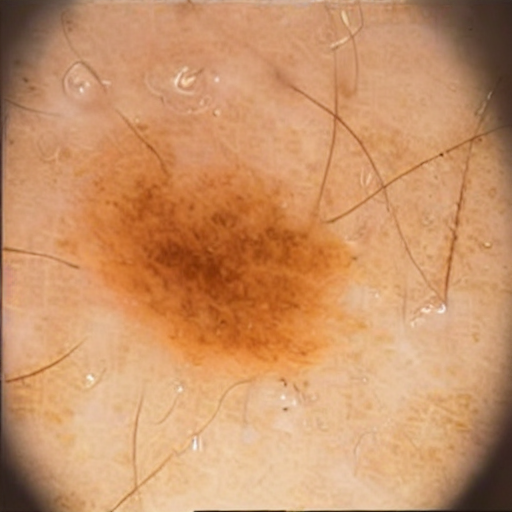

In [33]:
full_dataset[3][0]

# Performance results

In [19]:
artifacts = ['dark_corner', 'gel_bubble', 'ink', 'patches', 'ruler']

In [24]:
dataset_modes = [
    "whole", "background", "bbox", "bbox70", "bbox90",
"high_whole", "low_whole", "high_background", "low_background"
]
eval_dir = "/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2" 

In [25]:
results = {}

# Iterate through dataset modes and artifacts
for mode in dataset_modes:
    for artifact in artifacts:
        file_path = os.path.join(eval_dir, mode, f"all_metrics_ph2_augmented_{artifact}.pkl")

        # Check if file exists before attempting to load
        if os.path.exists(file_path):
            with open(file_path, "rb") as f:
                tmp = pickle.load(f)  # Load metrics dictionary

            # Compute mean values for each metric
            mean_metrics = {metric: np.mean(values) for metric, values in tmp.items()}

            # Store in results dictionary with MultiIndex structure
            results[(mode, artifact)] = mean_metrics
        else:
            print(f"Warning: File not found - {file_path}")

# Convert results dictionary to a MultiIndex DataFrame
df_results = pd.DataFrame.from_dict(results, orient="index")

In [26]:
df_results

AUROC  Accuracy    Recall  Precision
whole           dark_corner  0.954676  0.891463  0.719841   0.831895
                gel_bubble   0.942797  0.847561  0.751984   0.620986
                ink          0.929229  0.832317  0.871429   0.618223
                patches      0.967069  0.916707  0.672619   0.879444
                ruler        0.945593  0.852683  0.723413   0.665855
background      dark_corner  0.836527  0.877317  0.621825   0.727273
                gel_bubble   0.855804  0.857439  0.650397   0.671429
                ink          0.819726  0.852317  0.726190   0.648611
                patches      0.859840  0.872805  0.602381   0.755000
                ruler        0.846990  0.872683  0.646825   0.706984
bbox            dark_corner  0.831907  0.847805  0.603175   0.655311
                gel_bubble   0.842716  0.852561  0.605952   0.699286
                ink          0.838633  0.852683  0.593651   0.736783
                patches      0.849063  0.862927  0.527381   0.755556
                ruler        0.796366  0.852805  0.558730   0.697619
bbox70          dark_corner  0.716416  0.799024  0.435714   0.599359
                gel_bubble   0.744682  0.754146  0.527381   0.514111
                ink          0.730053  0.681829  0.558730   0.372967
                patches      0.760240  0.867927  0.457937   0.825000
                ruler        0.697947  0.804024  0.507937   0.577619
bbox90          dark_corner  0.728738  0.808780  0.233333   0.514286
                gel_bubble   0.789081  0.818659  0.302778   0.533333
                ink          0.762804  0.779024  0.331349   0.560000
                patches      0.764999  0.809146  0.183333   0.633333
                ruler        0.775259  0.818659  0.208333   0.666667
high_whole      dark_corner  0.832362  0.884146  0.445437   0.825000
                gel_bubble   0.835943  0.859756  0.513393   0.762500
                ink          0.892996  0.859756  0.363095   0.816667
                patches      0.841068  0.853659  0.256944   0.750000
                ruler        0.778009  0.865854  0.378472   0.659722
low_whole       dark_corner  0.899866  0.837927  0.674603   0.650357
                gel_bubble   0.874258  0.744390  0.725397   0.536025
                ink          0.863290  0.587927  0.851190   0.343500
                patches      0.915521  0.867805  0.699603   0.692222
                ruler        0.893569  0.774024  0.753175   0.565278
high_background dark_corner  0.811957  0.890244  0.528274   0.854167
                gel_bubble   0.801083  0.884146  0.492560   0.837500
                ink          0.782685  0.890244  0.528274   0.854167
                patches      0.793567  0.878049  0.492560   0.812500
                ruler        0.827362  0.878049  0.464782   0.837500
low_background  dark_corner  0.848973  0.882317  0.561508   0.804762
                gel_bubble   0.863713  0.892195  0.558730   0.848095
                ink          0.816348  0.887073  0.590079   0.821429
                patches      0.878687  0.897195  0.536508   0.910000
                ruler        0.852804  0.882317  0.561508   0.804762

In [89]:
artifacts = [ 
          'dark_corner_6_clean',
          'gel_bubble_1_clean', 
          'ink_4_no_ruler_clean',
            'patches_3_clean',
            'ruler_1_clean',]
dataset_modes = [
    "whole", "background", "bbox", "bbox70", "bbox90",
"high_whole", "low_whole", "high_background", "low_background"
]
eval_dir = "/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2" 

In [91]:
results = {}

# Iterate through dataset modes and artifacts
for mode in dataset_modes:
    for artifact in artifacts:
        file_path = os.path.join(eval_dir, mode, f"all_metrics_ph2_clean_{artifact}.pkl")

        # Check if file exists before attempting to load
        if os.path.exists(file_path):
            with open(file_path, "rb") as f:
                tmp = pickle.load(f)  # Load metrics dictionary

            # Compute mean values for each metric
            mean_metrics = {metric: np.mean(values) for metric, values in tmp.items()}

            # Store in results dictionary with MultiIndex structure
            results[(mode, artifact)] = mean_metrics
        else:
            print(f"Warning: File not found - {file_path}")

# Convert results dictionary to a MultiIndex DataFrame
df_results = pd.DataFrame.from_dict(results, orient="index")

In [92]:
# Better results -> run after finishing the writing 
df_results[['AUROC']].round(3)

AUROC
whole           dark_corner_6_clean   0.978
                gel_bubble_1_clean    0.973
                ink_4_no_ruler_clean  0.959
                patches_3_clean       0.976
                ruler_1_clean         0.966
background      dark_corner_6_clean   0.888
                gel_bubble_1_clean    0.893
                ink_4_no_ruler_clean  0.877
                patches_3_clean       0.860
                ruler_1_clean         0.890
bbox            dark_corner_6_clean   0.881
                gel_bubble_1_clean    0.868
                ink_4_no_ruler_clean  0.873
                patches_3_clean       0.896
                ruler_1_clean         0.880
bbox70          dark_corner_6_clean   0.832
                gel_bubble_1_clean    0.852
                ink_4_no_ruler_clean  0.826
                patches_3_clean       0.810
                ruler_1_clean         0.856
bbox90          dark_corner_6_clean   0.875
                gel_bubble_1_clean    0.824
                ink_4_no_ruler_clean  0.806
                patches_3_clean       0.809
                ruler_1_clean         0.817
high_whole      dark_corner_6_clean   0.487
                gel_bubble_1_clean    0.414
                ink_4_no_ruler_clean  0.484
                patches_3_clean       0.427
                ruler_1_clean         0.335
low_whole       dark_corner_6_clean   0.836
                gel_bubble_1_clean    0.860
                ink_4_no_ruler_clean  0.781
                patches_3_clean       0.818
                ruler_1_clean         0.855
high_background dark_corner_6_clean   0.842
                gel_bubble_1_clean    0.859
                ink_4_no_ruler_clean  0.840
                patches_3_clean       0.850
                ruler_1_clean         0.847
low_background  dark_corner_6_clean   0.874
                gel_bubble_1_clean    0.850
                ink_4_no_ruler_clean  0.893
                patches_3_clean       0.803
                ruler_1_clean         0.889

# Visualize Dreambooth Inpainting

In [72]:
df['label'].head(20)

0     1
1     1
2     0
3     0
4     0
5     0
6     0
7     0
8     1
9     1
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
Name: label, dtype: int64

In [63]:
datasets = {
}
for artifact in artifacts:
    datasets[artifact] = PH2Dataset(df, image_dir, mode="whole", return_pil=True, clean=artifact)

In [67]:
datasets['original'] = PH2Dataset(df, image_dir, mode="whole", return_pil=True)

In [68]:
datasets.keys()

dict_keys(['dark_corner_6_clean', 'gel_bubble_1_clean', 'ink_4_no_ruler_clean', 'patches_3_clean', 'ruler_1_clean', 'original'])

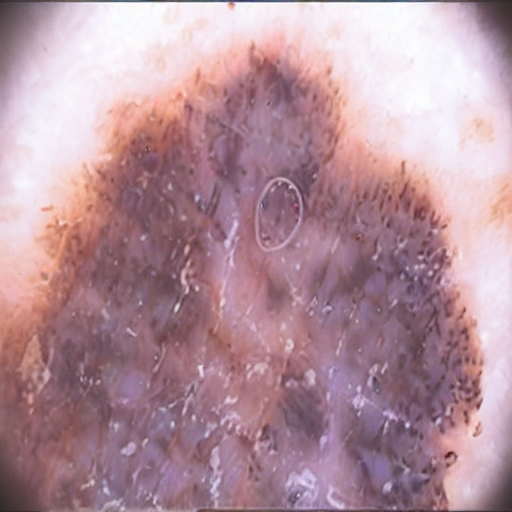

In [65]:
datasets['dark_corner_6_clean'][0][0]

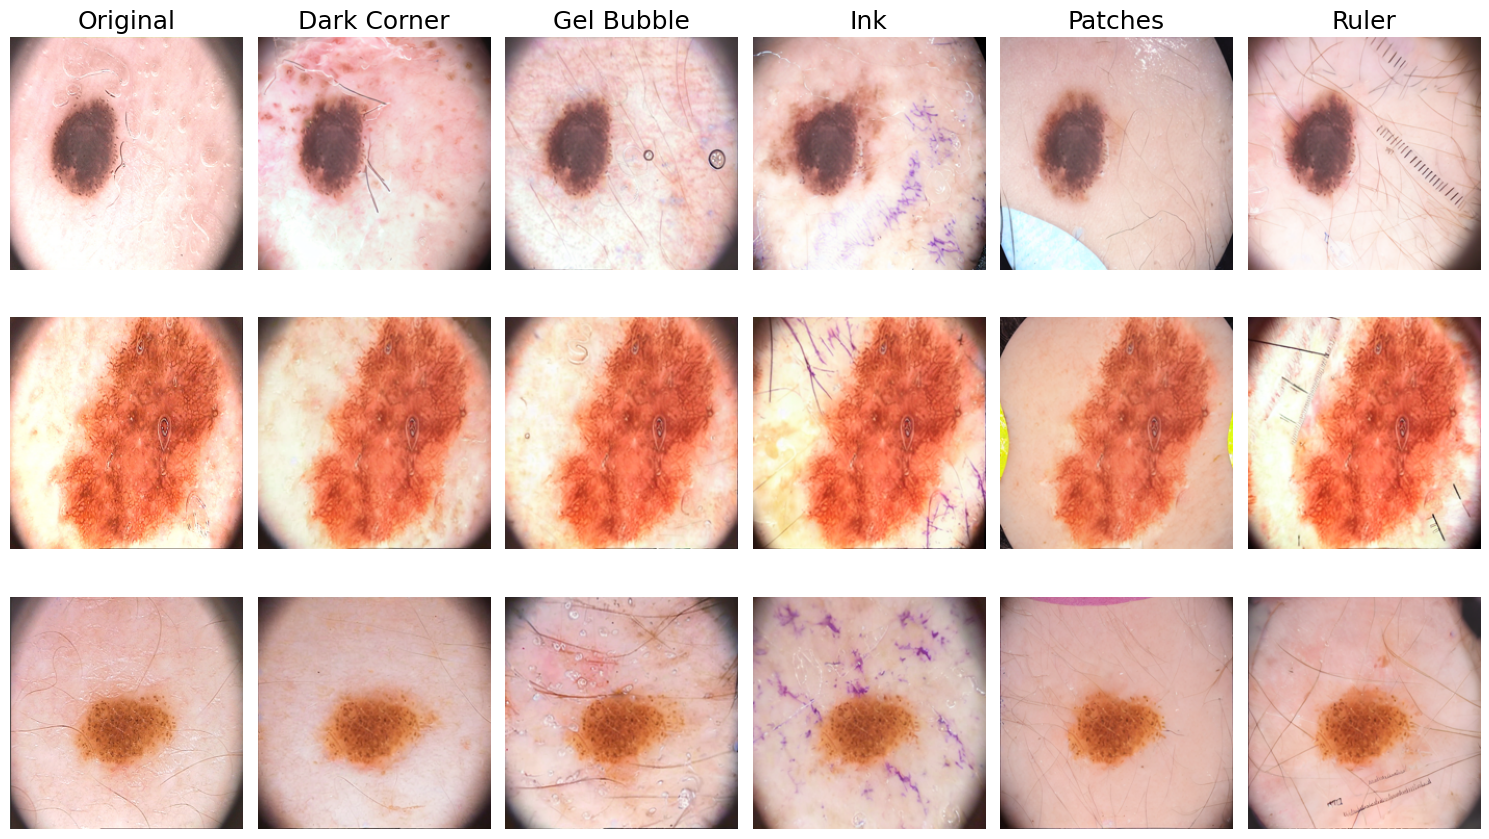

In [86]:
# Sample indices to visualize
# 4, 136, 141, 151, 185

indices = [76, 11, 151]  # Modify these as needed

# Dataset keys
keys = ['original', 'dark_corner_6_clean', 'gel_bubble_1_clean', 'ink_4_no_ruler_clean', 'patches_3_clean', 'ruler_1_clean']
key_mapping = {
    'original': 'Original', 
    'dark_corner_6_clean': 'Dark Corner', 
    'gel_bubble_1_clean': 'Gel Bubble', 
    'ink_4_no_ruler_clean': 'Ink', 
    'patches_3_clean': 'Patches', 
    'ruler_1_clean': 'Ruler',
}


# Create a figure with appropriate size
fig, axes = plt.subplots(nrows=3, ncols=len(keys), figsize=(15, 9))

for row_idx, i in enumerate(indices):
    for col_idx, key in enumerate(keys):
        # Retrieve the image
        image = datasets[key][i][0].resize((224, 224))  # Accessing the PIL image
        
        # Display the image in the grid
        axes[row_idx, col_idx].imshow(image, cmap='gray')  # Adjust cmap if images are grayscale
        axes[row_idx, col_idx].axis('off')
        
        # Set title only for the top row
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(key_mapping[key], fontsize=18)

plt.savefig("figs/dreambooth_grid.png", dpi=300)
# Adjust layout and show the plot
plt.tight_layout()
plt.show()